In [74]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import superstats as sup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [2]:
NUM_STEPS = 480
NUM_SAMPLES = 1000

## Context

In [3]:
def generate_context(num_steps):
    conditions = [
        (0.5, 0.5),   # high difficulty, high reward
        (0.5, -0.5),  # high difficulty, low reward
        (-0.5, 0.5),  # low difficulty, high reward
        (-0.5, -0.5), # low difficulty, low reward
    ]
    num_blocks = (num_steps + 59) // 60
    conditions = (conditions * ((num_blocks + len(conditions) - 1) // len(conditions)))[:num_blocks]
    np.random.shuffle(conditions)
    difficulty = []
    reward = []
    remaining_steps = num_steps
    for difficulty_code, reward_code in conditions:
        block_steps = min(60, remaining_steps)
        difficulty.extend([difficulty_code] * block_steps)
        reward.extend([reward_code] * block_steps)
        remaining_steps -= block_steps
    return {
        "difficulty": difficulty,
        "reward": reward,
    }

In [4]:
context_simulator = sup.ContextSimulator(
    simulator=generate_context,
    is_batched=False
)

## Prior

In [5]:
formula = sup.Formula([
    "v = v_0 + b_v_1 * difficulty + b_v_2 * reward + b_v_3 * difficulty * reward",
    "a = a_0 + b_a_1 * difficulty + b_a_2 * reward + b_a_3 * difficulty * reward",
    "tau = tau_0 + b_tau_1 * difficulty + b_tau_2 * reward + b_tau_3 * difficulty * reward",
])

prior = sup.JointPrior(
    v_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.15),
    ),
    b_v_1=sup.Prior("normal", loc=0.0, scale=2.0),
    b_v_2=sup.Prior("normal", loc=0.0, scale=2.0),
    b_v_3=sup.Prior("normal", loc=0.0, scale=2.0),
    a_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.15),
    ),
    b_a_1=sup.Prior("normal", loc=0.0, scale=2.0),
    b_a_2=sup.Prior("normal", loc=0.0, scale=2.0),
    b_a_3=sup.Prior("normal", loc=0.0, scale=2.0),
    tau_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=0.0, scale=0.75),
        sigma=sup.Prior("halfnormal", scale=0.075),
    ),
    b_tau_1=sup.Prior("normal", loc=0.0, scale=0.5),
    b_tau_2=sup.Prior("normal", loc=0.0, scale=0.5),
    b_tau_3=sup.Prior("normal", loc=0.0, scale=0.5),
    bias=0.5,
    p_missing=sup.Prior("beta", a=1.5, b=15.0),
)

In [6]:
missing_process = sup.simulation.RandomMissingProcess(
    missing_value=-1,
)

model = sup.Model(
    prior=prior,
    simulator=sup.simulation.sample_ddm,
    formula_link_function={
        'v': sup.LinkFunction(bounds=(0.0, 8.0)),
        'a': sup.LinkFunction(bounds=(0.0, 6.0)),
        'tau': sup.LinkFunction(bounds=(0.0, 1.0))
    }, 
    formula=formula,
    context_simulator=context_simulator,
    design_context=('difficulty', 'reward'),
    missing=missing_process,
)

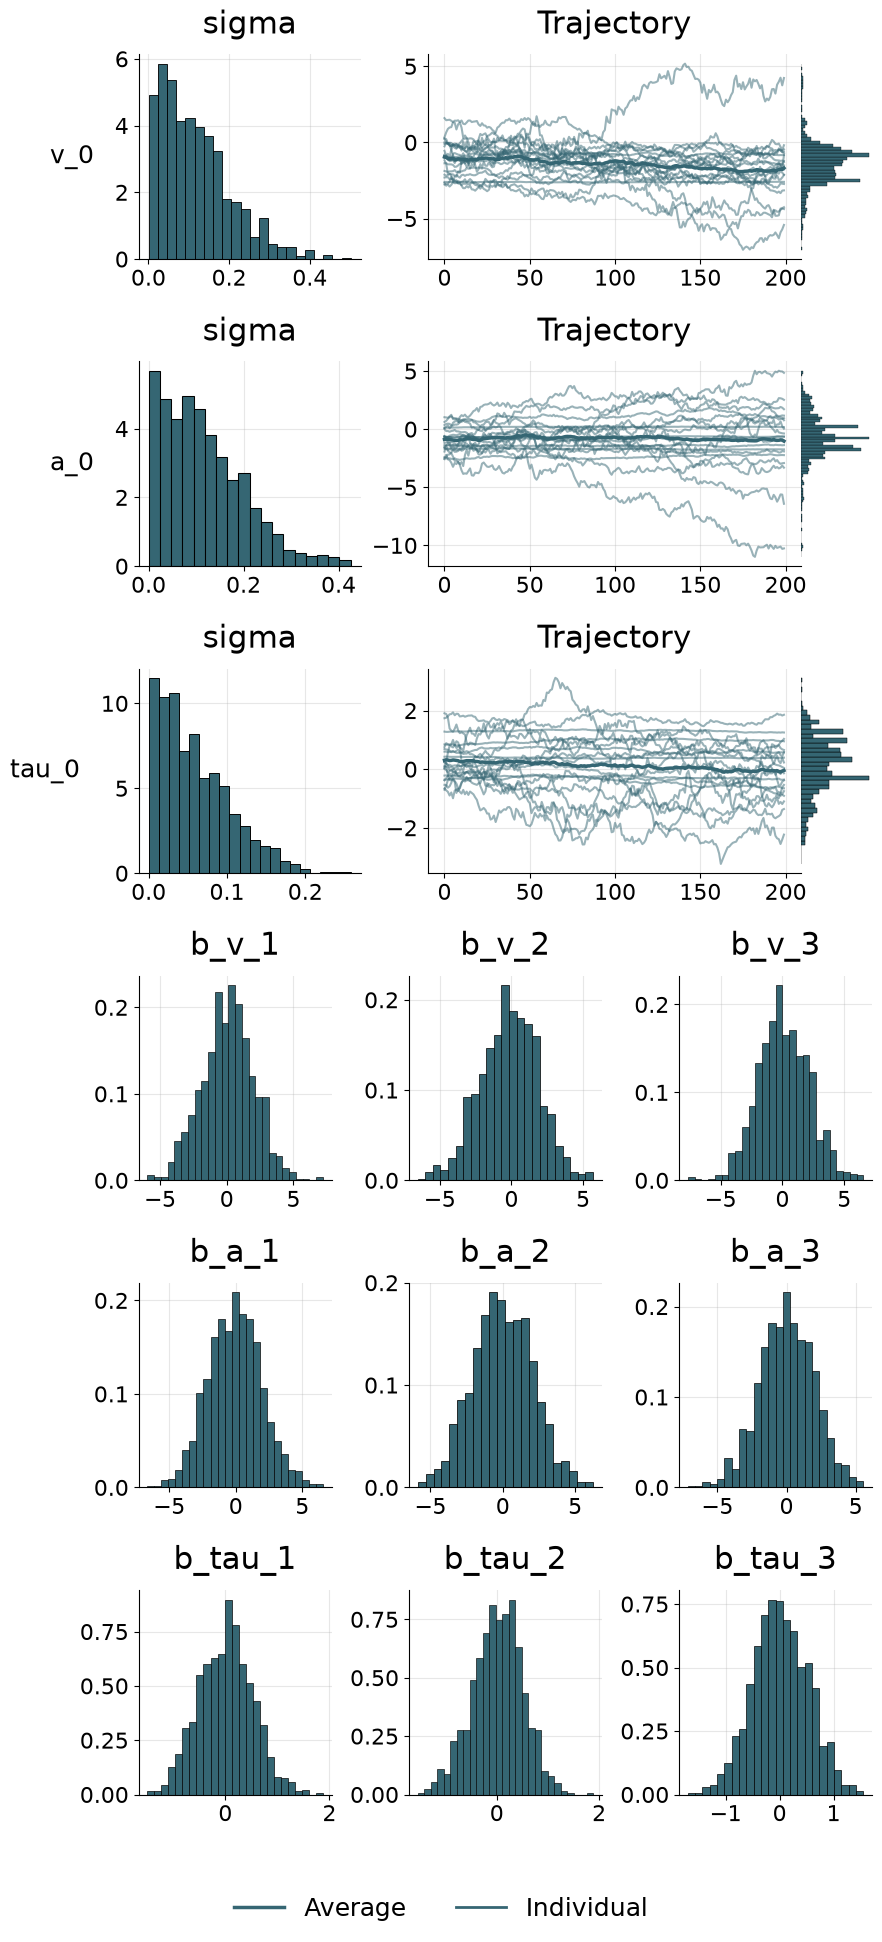

In [7]:
fig = model.plot_joint_prior()

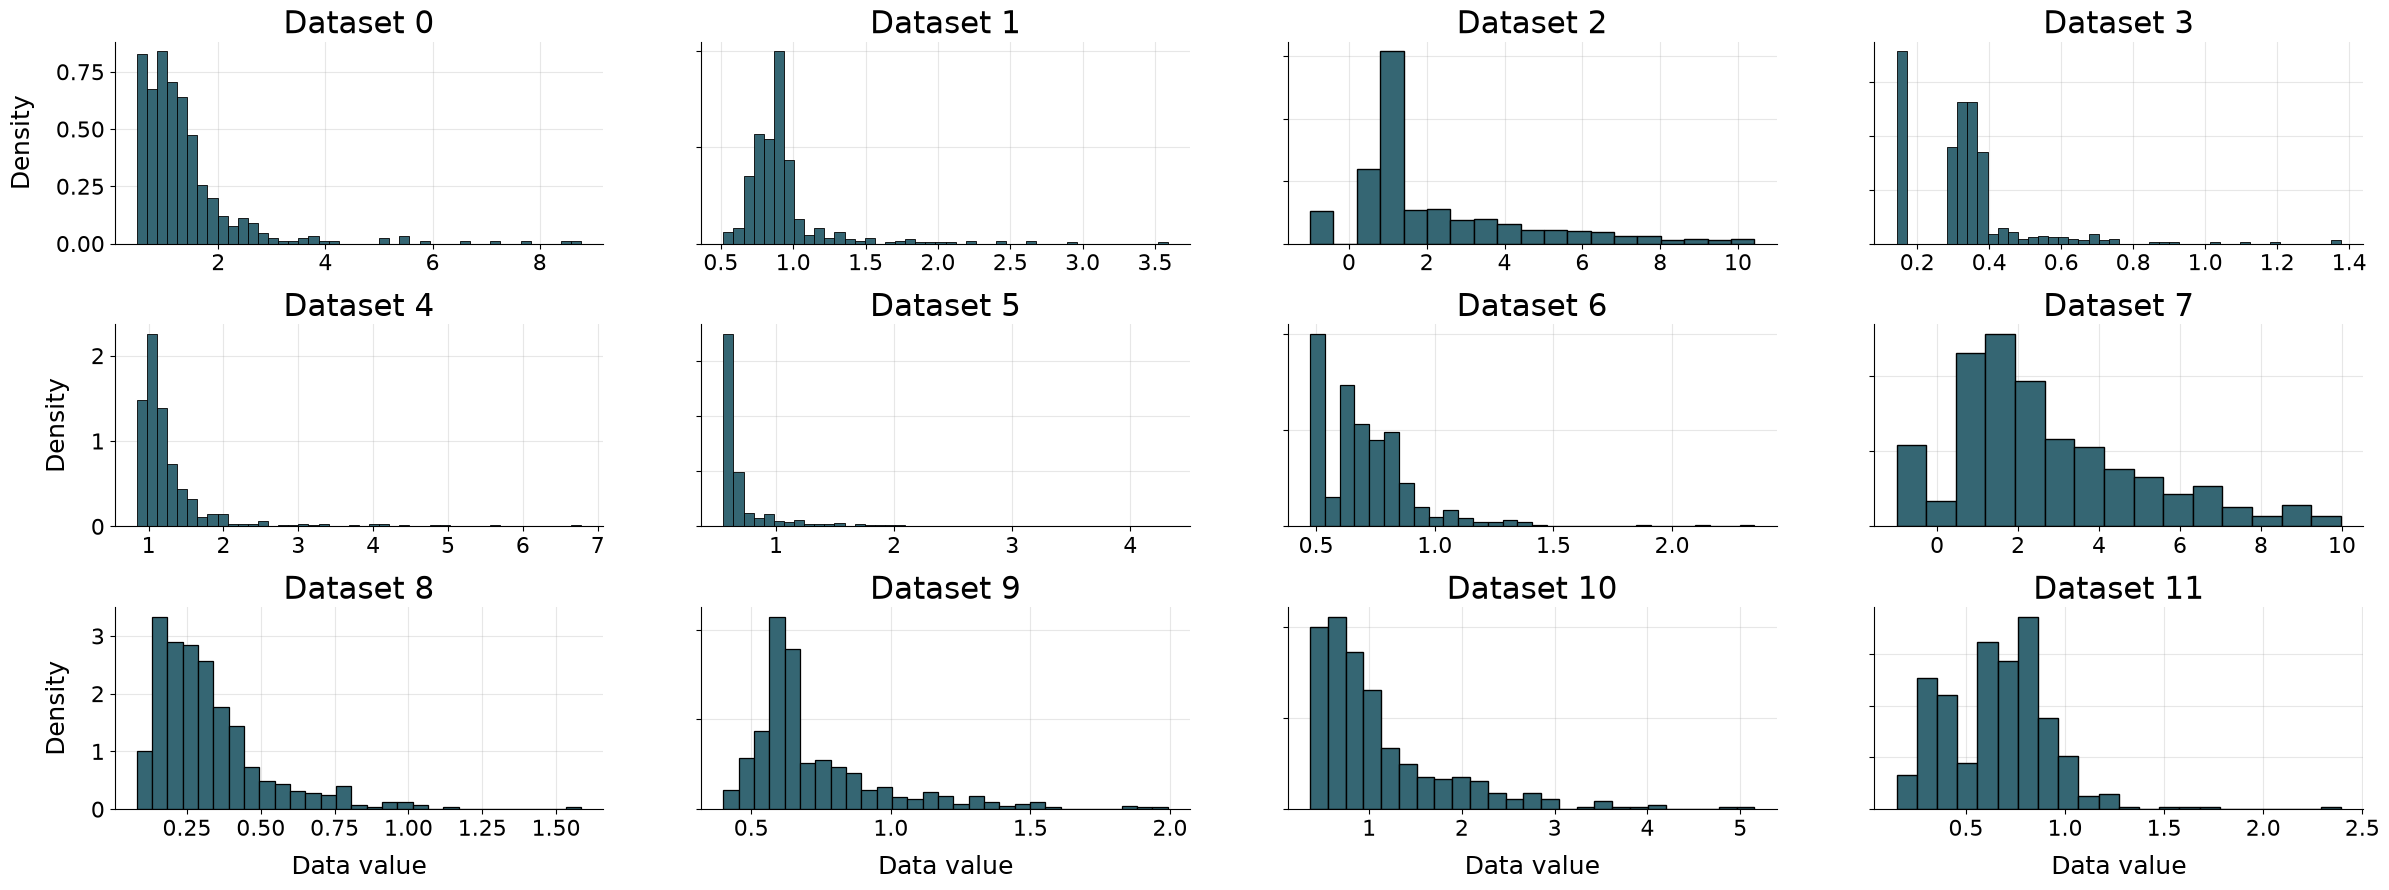

In [8]:
fig = model.plot_push_forward(
    batch_size=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist"
)

## Approximator Training

In [9]:
workflow = sup.Workflow(
    model=model,
    approximator="marginal",
    mode="smoothing",
    checkpoint_filepath="checkpoints/ms_study_ddm_regressors_v02"
)

In [10]:
# train_data = model.sample(
#     batch_size=30_000,
#     num_steps=NUM_STEPS
# )

# val_data = model.sample(
#     batch_size=200,
#     num_steps=NUM_STEPS
# )

In [11]:
# history = workflow.fit_offline(
#     data=train_data,
#     validation_data=val_data,
#     epochs=50,
#     batch_size=32
# )

In [ ]:
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=100,
    num_batches_per_epoch=1000,
    batch_size=32
)

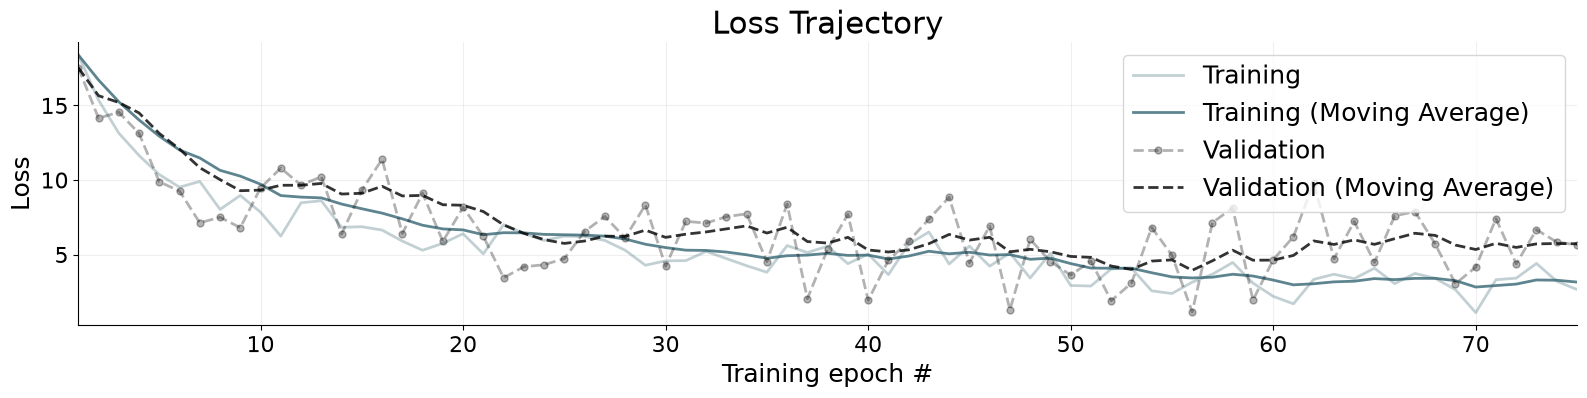

In [12]:
fig = workflow.plot_history(workflow.history)

## Model Verification

In [13]:
targets = model.sample(batch_size=100, num_steps=NUM_STEPS)

In [14]:
samples = workflow.sample(data=targets, num_samples=500, batch_size=10)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

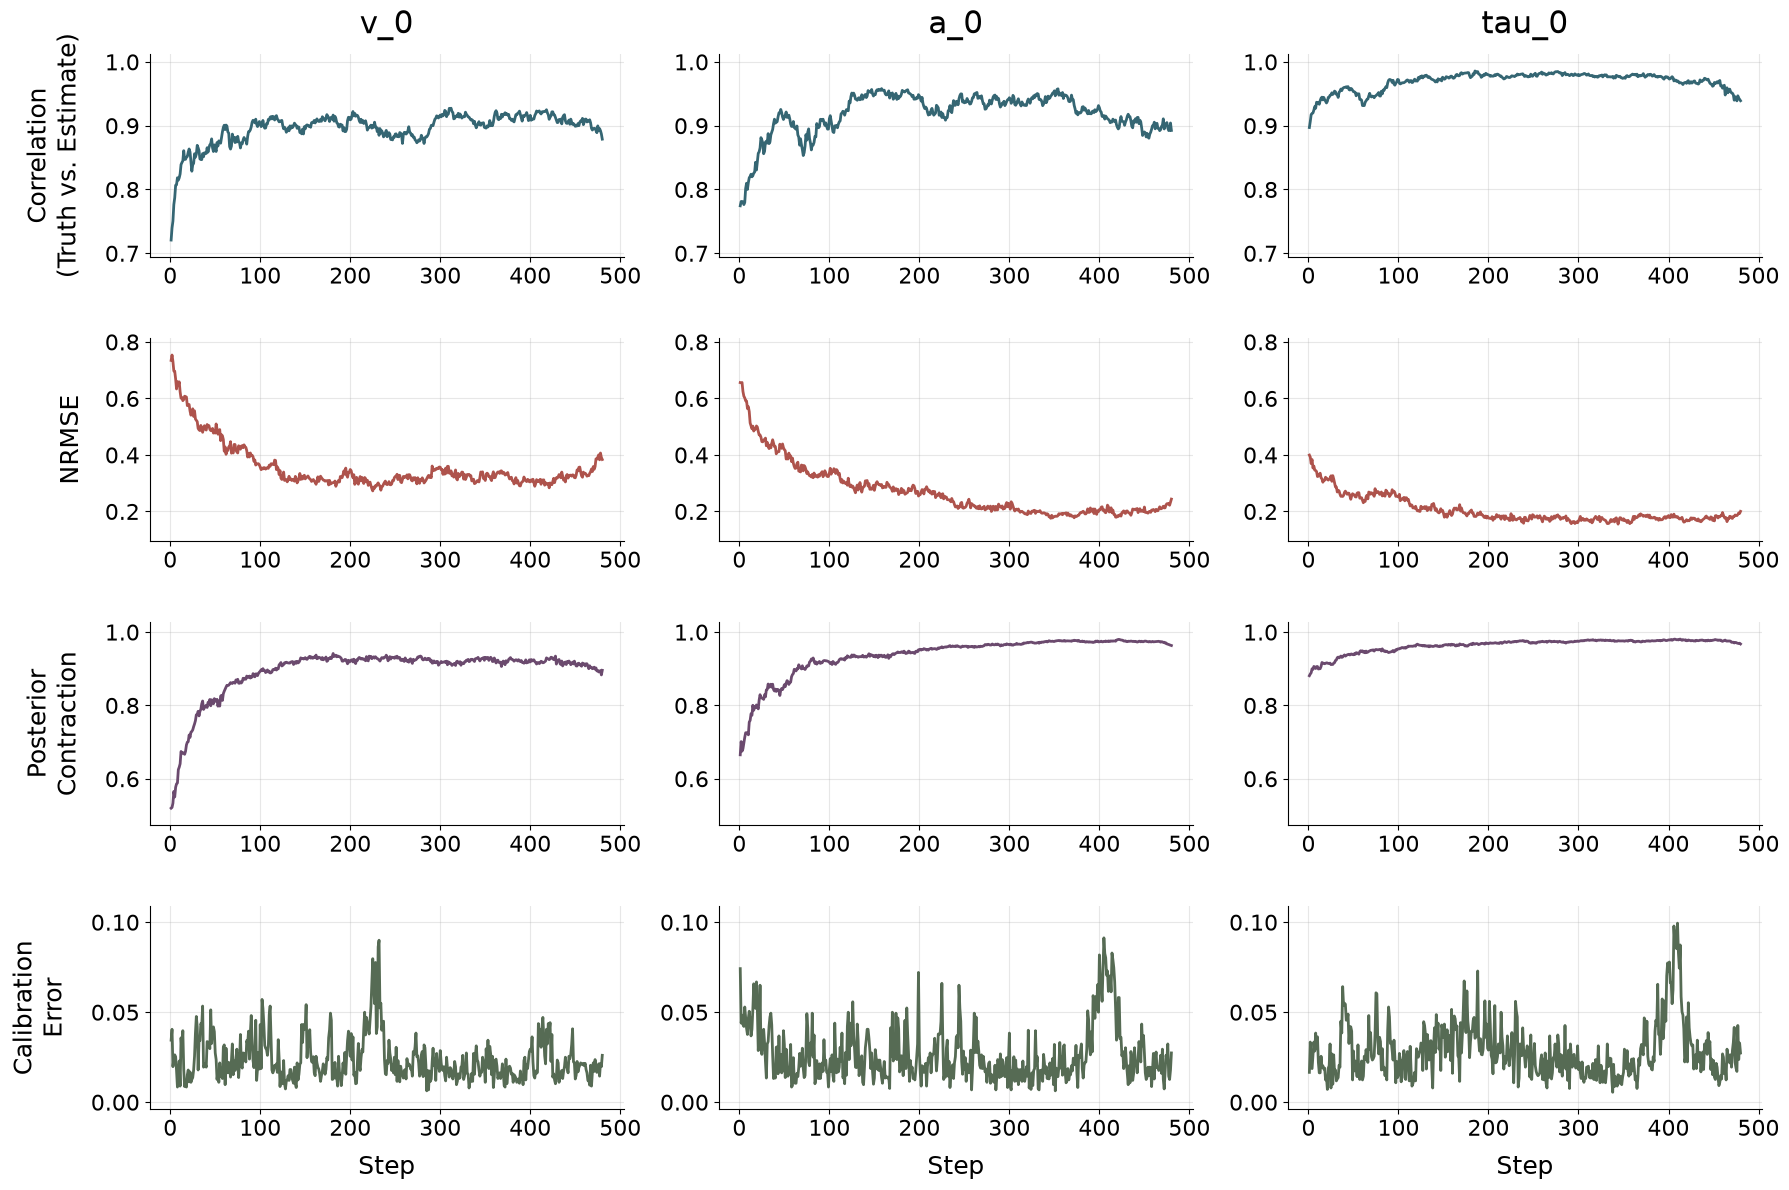

In [15]:
fig = workflow.verify_time_varying(targets=targets, estimates=samples)

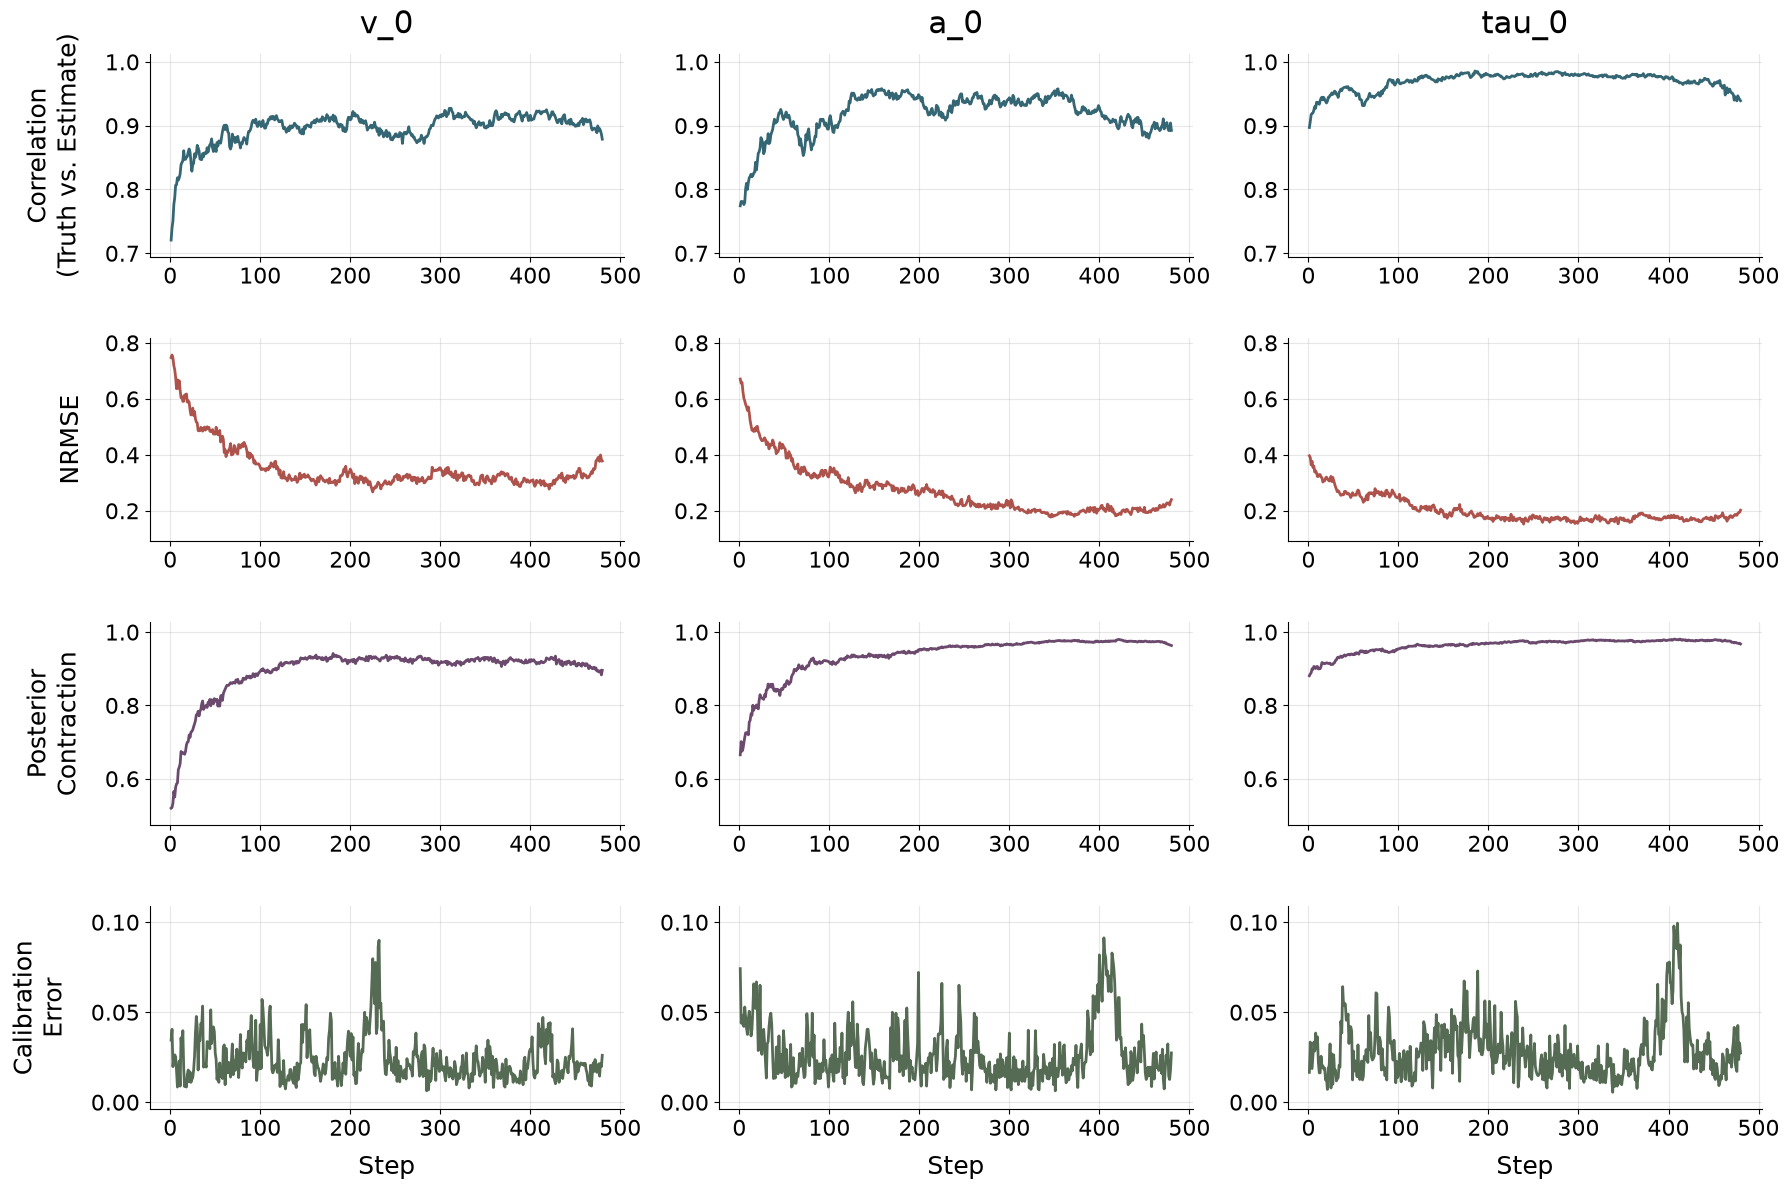

In [16]:
fig = workflow.verify_time_varying(targets=targets, estimates=samples)

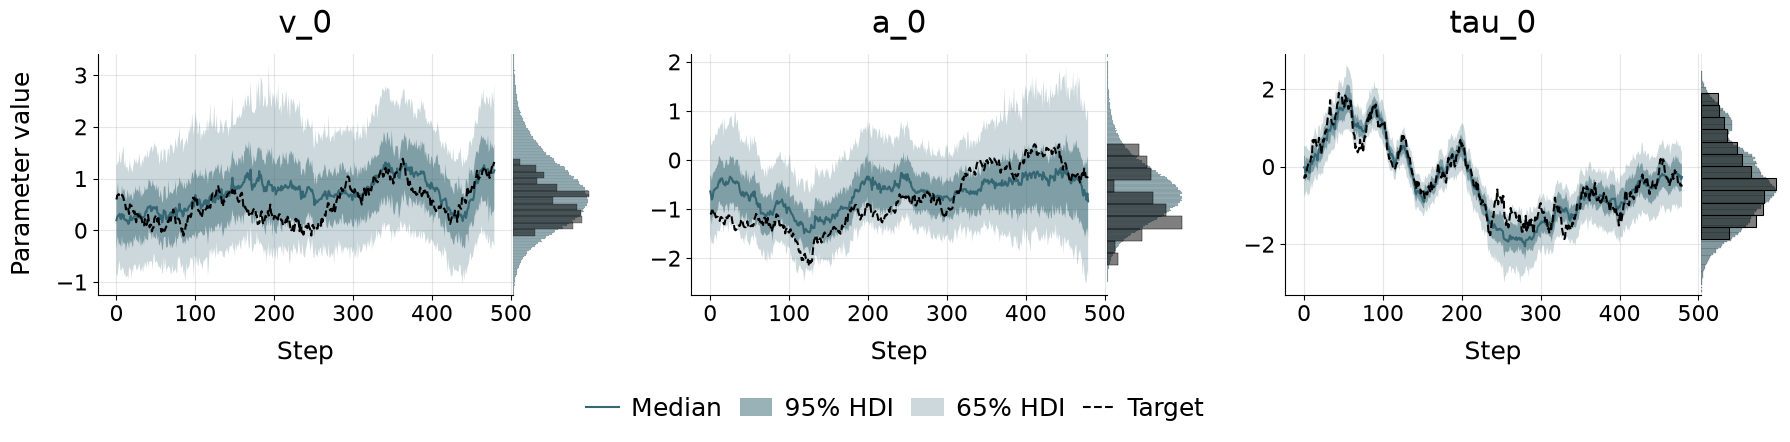

In [17]:
fig = workflow.plot_time_varying_posterior(
    estimates=samples,
    targets=targets,
    data_idx=3
)

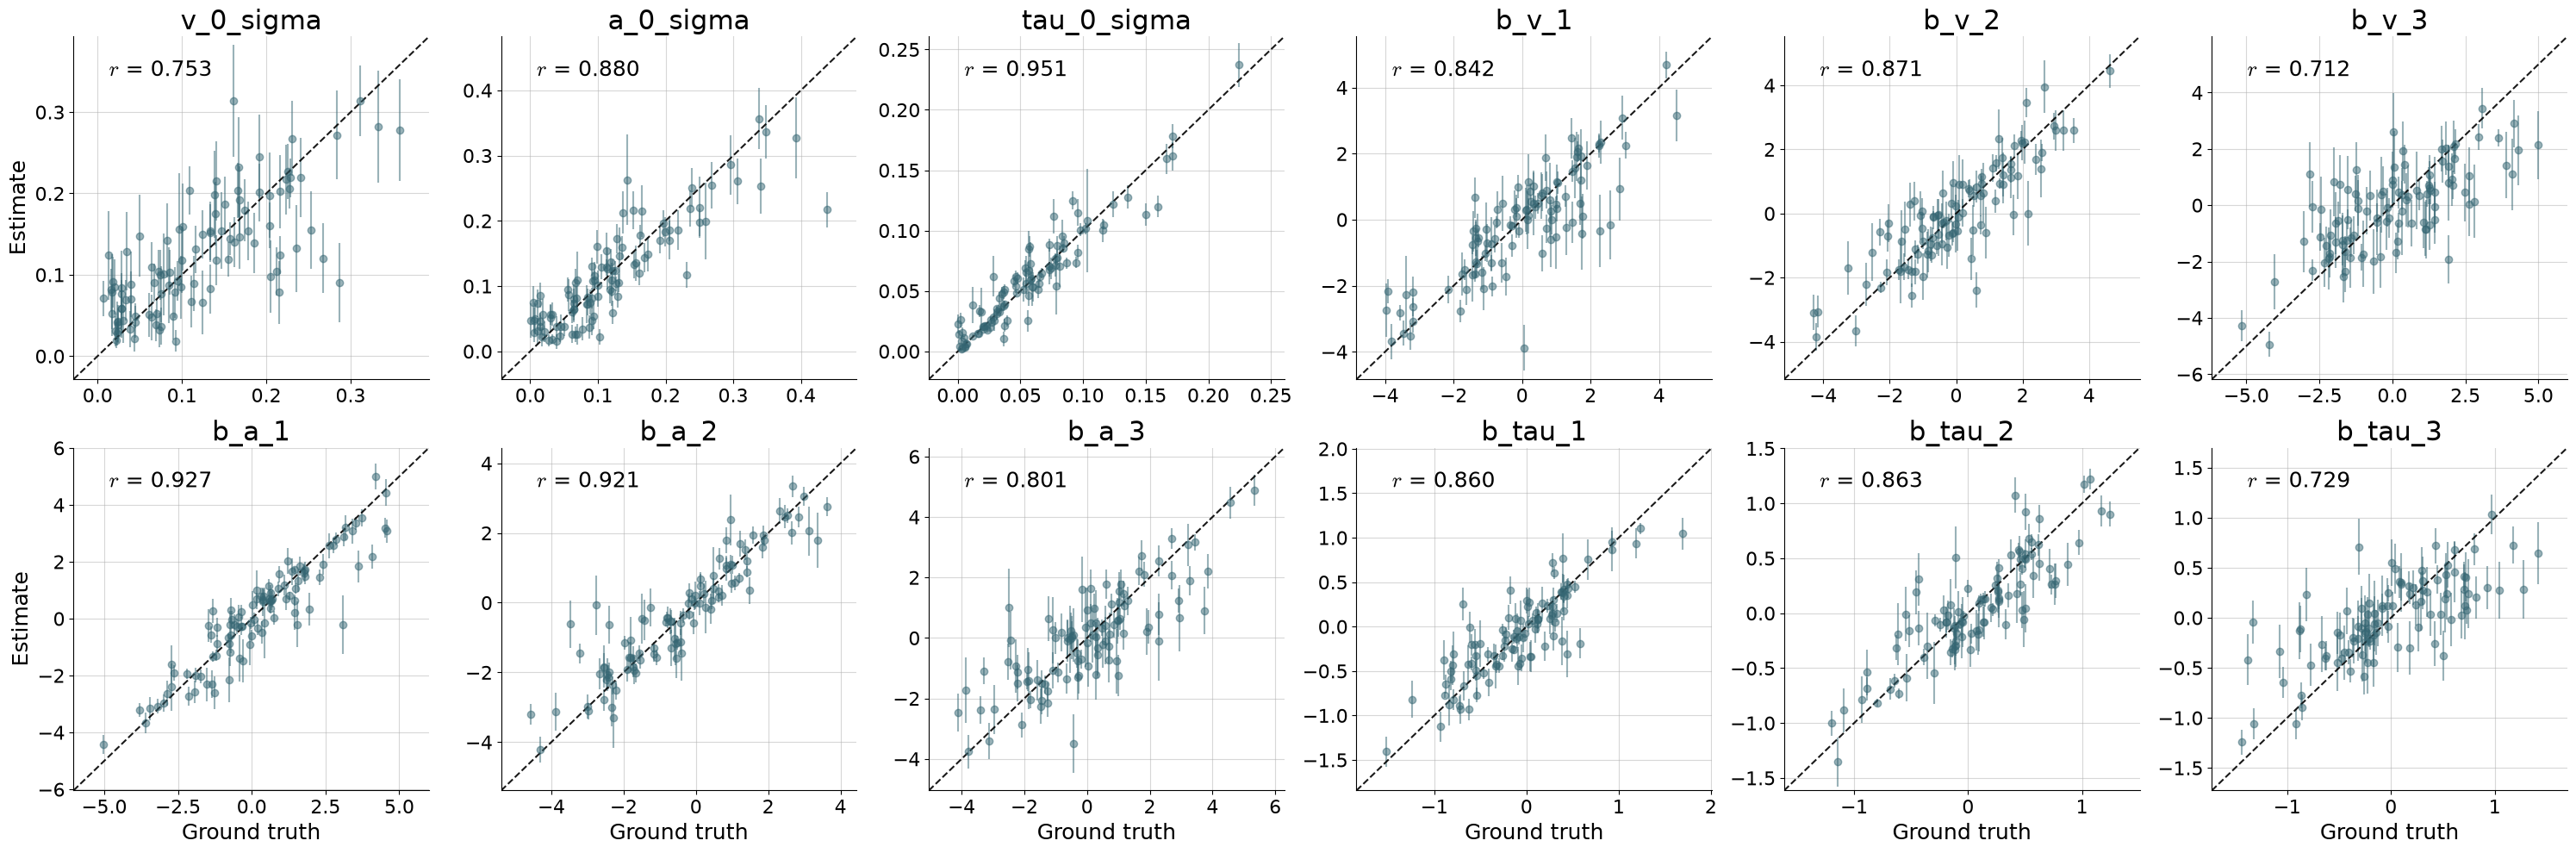

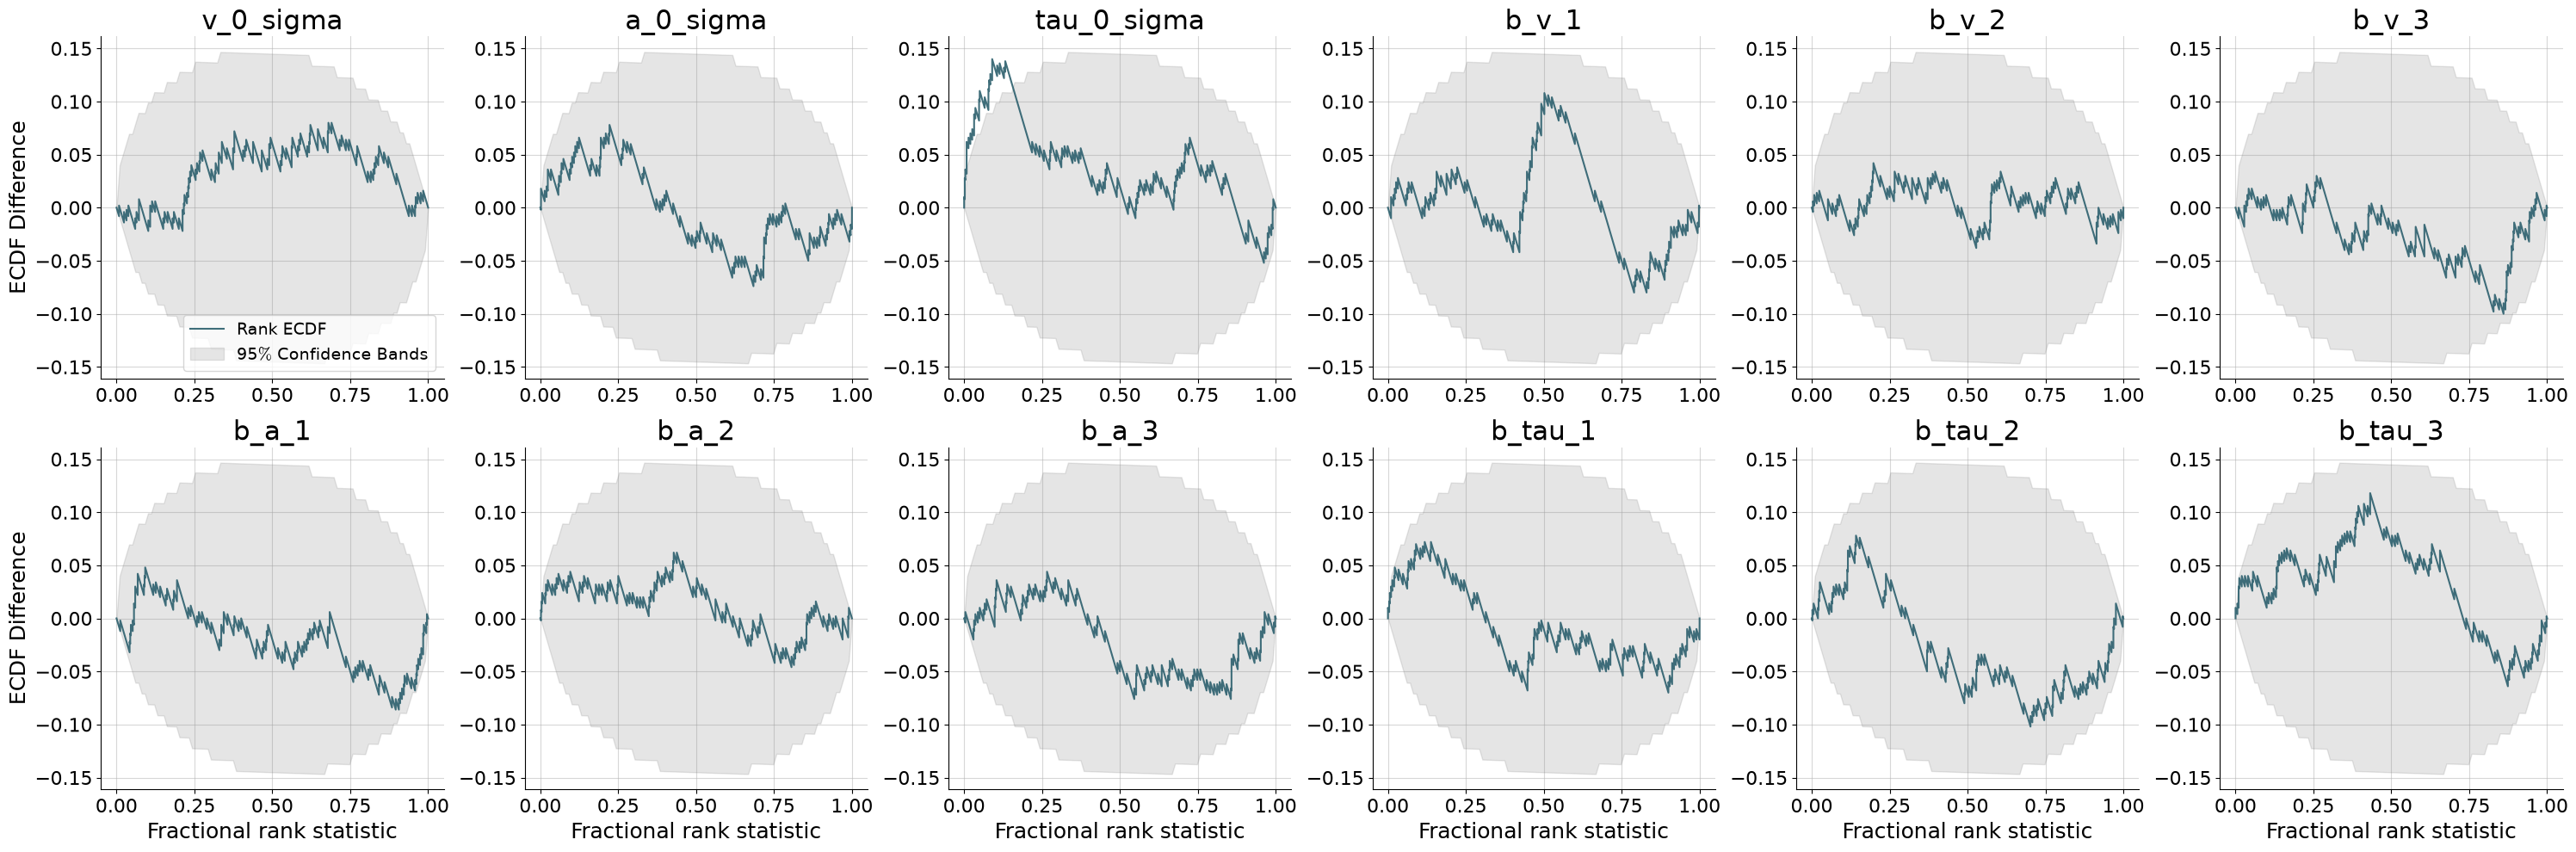

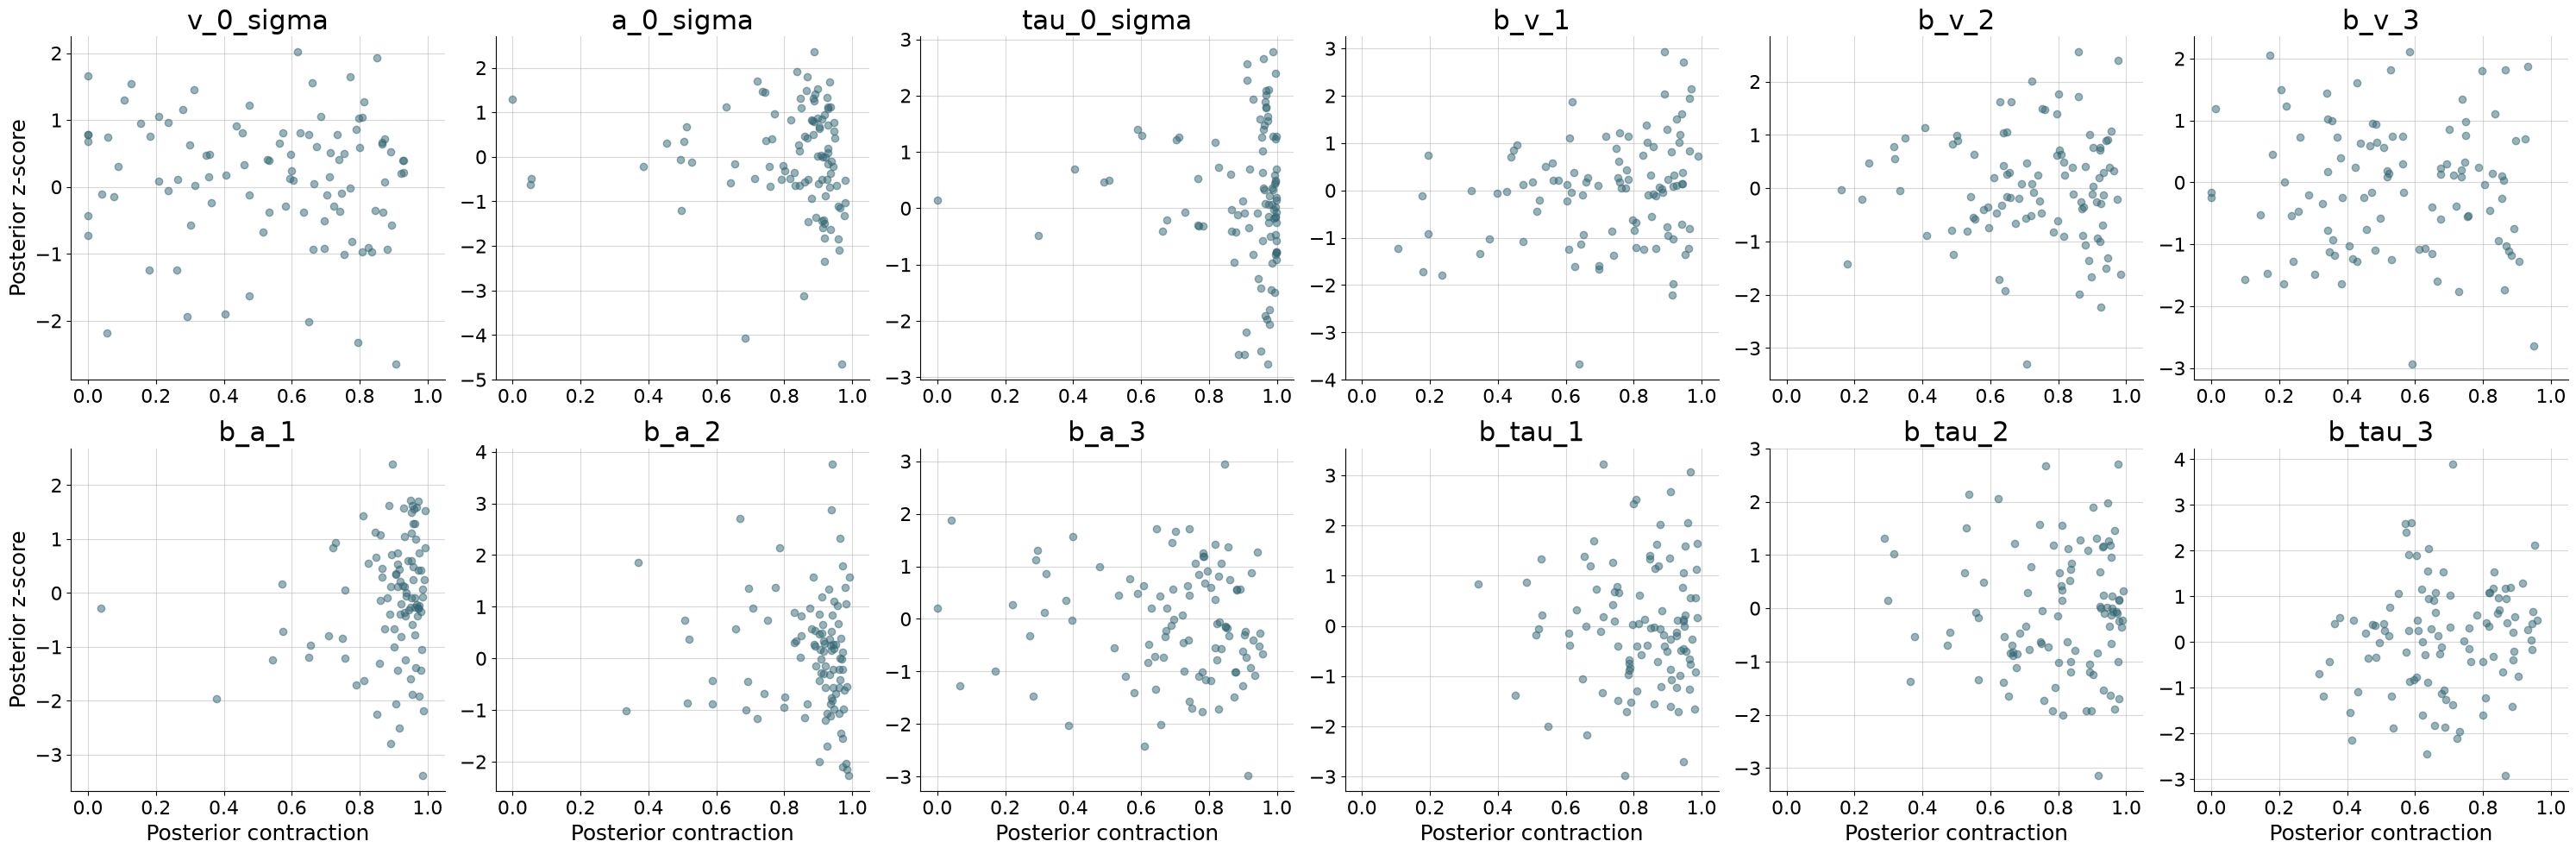

In [18]:
from scipy.stats import median_abs_deviation


fig_recovery, fig_calibration, fig_z_score_contraction = workflow.verify_time_invariant(
    estimates=samples,
    targets=targets,
    uncertainty_agg=median_abs_deviation
)

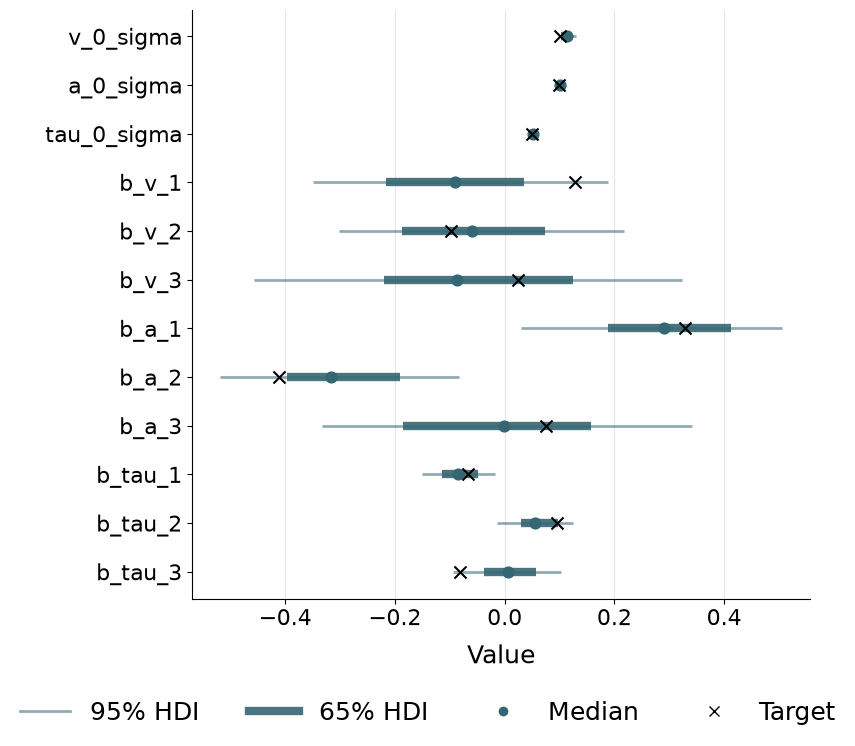

In [19]:
fig = workflow.plot_forest(
    estimates=samples,
    targets=targets,
    aggregation=np.median
)

## Data Fitting

In [48]:
data = pd.read_csv("data/ms_study_01.csv")

# Encode missing response times and choices as -1
missing_rows = data["rt"].isna()
data.loc[missing_rows, ["rt", "correct"]] = -1

# Recode experimental variables
recode = {
    "low": -0.5,
    "high": 0.5,
}
data[["difficulty", "reward"]] = (
    data[["difficulty", "reward"]].replace(recode)
)

# Rename variables
data = data.rename(
    columns={
        "rt": "response_time",
        "correct": "choice",
    }
)

# Subject information
SUBJECTS = data["id"].unique()
NUM_SUBJECTS = len(SUBJECTS)

# Check whether all subjects have the same number of steps
steps_per_subject = data.groupby("id").size()

if steps_per_subject.nunique() != 1:
    raise ValueError(
        "Subjects have different numbers of steps:\n"
        f"{steps_per_subject.sort_values()}"
    )

num_steps = int(steps_per_subject.iloc[0])

# Assign a zero-based step index within each subject
data["step"] = data.groupby("id").cumcount()

# Variables to reshape
variables = [
    "response_time",
    "choice",
    "difficulty",
    "reward",
]

# Reshape each variable to (NUM_SUBJECTS, num_steps)
data_dict = {
    variable: (
        data.pivot(
            index="id",
            columns="step",
            values=variable,
        )
        .reindex(SUBJECTS)
        .to_numpy()
    )
    for variable in variables
}

# Add one-based time steps: 1, 2, ..., num_steps
data_dict["time_steps"] = np.tile(
    np.arange(1, num_steps + 1),
    (NUM_SUBJECTS, 1),
)

# True where response_time is missing (-1), otherwise False
data_dict["missing_mask"] = (
    data_dict["response_time"] == -1
)

# Verify the shape of every array
expected_shape = (NUM_SUBJECTS, num_steps)

assert all(
    values.shape == expected_shape
    for values in data_dict.values()
)

print({
    name: values.shape
    for name, values in data_dict.items()
})

{'response_time': (77, 480), 'choice': (77, 480), 'difficulty': (77, 480), 'reward': (77, 480), 'time_steps': (77, 480), 'missing_mask': (77, 480)}


In [42]:
data = data.rename(
    columns={
        "rt": "response_time",
        "correct": "choice",
    }
)

variables = ["response_time", "choice", "difficulty", "reward"]

steps_per_subject = data.groupby("id").size()

if steps_per_subject.nunique() != 1:
    raise ValueError(
        "Subjects have different numbers of steps:\n"
        f"{steps_per_subject.value_counts().sort_index()}"
    )

num_steps = int(steps_per_subject.iloc[0])
data["step"] = data.groupby("id").cumcount()

data_dict = {
    variable: (
        data.pivot(index="id", columns="step", values=variable)
        .reindex(SUBJECTS)
        .to_numpy()
    )
    for variable in variables
}

assert all(
    values.shape == (NUM_SUBJECTS, num_steps)
    for values in data_dict.values()
)

In [ ]:
estimates = workflow.sample(
    data=data_dict,
    num_samples=1000
)

### Time varying estimates

In [ ]:
param_names = ["v_0", "a_0", "tau_0"]

param_bounds = {
    "v_0": (0.0, 8.0),
    "a_0": (0.0, 6.0),
    "tau_0": (0.0, 1.0),
}

MS_HIGH_FATIGUE = data.loc[
    (data["group"] == 1) & (data["cog_fatigue_high"] == 1),
    "id",
].unique()

MS_LOW_FATIGUE = data.loc[
    (data["group"] == 1) & (data["cog_fatigue_high"] == 0),
    "id",
].unique()

CONTROL_LOW_FATIGUE = data.loc[
    (data["group"] == 0) & (data["cog_fatigue_high"] == 0),
    "id",
].unique()

CONTROL_HIGH_FATIGUE = data.loc[
    (data["group"] == 0) & (data["cog_fatigue_high"] == 1),
    "id",
].unique()

subject_classes = {
    "MS - High fatigue": MS_HIGH_FATIGUE,
    "MS - Low fatigue": MS_LOW_FATIGUE,
    "Control - High fatigue": CONTROL_HIGH_FATIGUE,
    "Control - Low fatigue": CONTROL_LOW_FATIGUE,
}

transformed_estimates = {}
smoothed_estimates = {}

for param in param_names:
    posterior = estimates[param]
    posterior = posterior[..., 0]

    transformed = sup.utils.transformations.scaled_sigmoid(
        posterior,
        lower_bound=param_bounds[param][0],
        upper_bound=param_bounds[param][1],
    )

    transformed_estimates[param] = transformed

    smoothed_estimates[param] = sup.utils.plotting.smooth_trajectories(
        transformed,
        smoothing="sma",
        smoothing_window=30,
    )

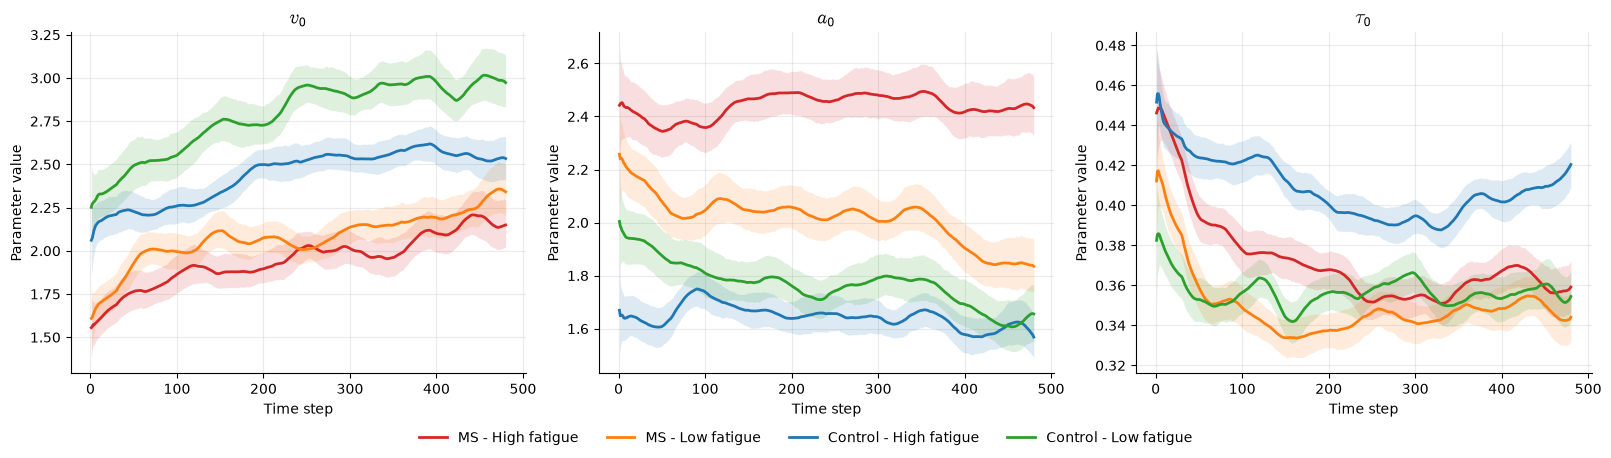

In [ ]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(param_names),
    figsize=(16, 4.5),
    sharex=True,
    constrained_layout=True,
)

time_steps = np.arange(1, num_steps + 1)

parameter_labels = {
    "v_0": r"$v_0$",
    "a_0": r"$a_0$",
    "tau_0": r"$\tau_0$",
}
class_colors = {
    "MS - High fatigue": "tab:red",
    "MS - Low fatigue": "tab:orange",
    "Control - High fatigue": "tab:blue",
    "Control - Low fatigue": "tab:green",
}

for col, param in enumerate(param_names):
    ax = axes[col]

    for class_name, class_subjects in subject_classes.items():
        subject_mask = np.isin(SUBJECTS, class_subjects)
        class_posterior = smoothed_estimates[param][subject_mask]
        group_posterior = class_posterior.mean(axis=0)
        trajectory_mean = group_posterior.mean(axis=0)

        trajectory_lower = np.quantile(
            group_posterior,
            0.025,
            axis=0,
        )
        trajectory_upper = np.quantile(
            group_posterior,
            0.975,
            axis=0,
        )
        color = class_colors[class_name]
        
        ax.plot(
            time_steps,
            trajectory_mean,
            color=color,
            linewidth=2,
            label=class_name,
        )
        ax.fill_between(
            time_steps,
            trajectory_lower,
            trajectory_upper,
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    lower, upper = param_bounds[param]

    ax.set_title(parameter_labels[param], fontsize=14)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Parameter value")
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="outside lower center",
    ncols=len(subject_classes),
    frameon=False,
)

sns.despine()

### Time-invariant estimates

In [87]:
time_invariant_params = [
    "v_0_sigma",
    "a_0_sigma",
    "tau_0_sigma",
    "b_v_1",
    "b_v_2",
    "b_v_3",
    "b_a_1",
    "b_a_2",
    "b_a_3",
    "b_tau_1",
    "b_tau_2",
    "b_tau_3",
]

class_names = list(subject_classes.keys())

class_colors = {
    "MS - High fatigue": "tab:red",
    "MS - Low fatigue": "tab:orange",
    "Control - High fatigue": "tab:blue",
    "Control - Low fatigue": "tab:green",
}

individual_posterior_medians = {}

for param in time_invariant_params:
    posterior = estimates[param]
    individual_posterior_medians[param] = np.median(
        posterior,
        axis=1,
    )

class_summaries = {}

for param in time_invariant_params:
    class_summaries[param] = {}

    individual_values = individual_posterior_medians[param]

    for class_name, class_subjects in subject_classes.items():
        subject_mask = np.isin(SUBJECTS, class_subjects)
        class_values = individual_values[subject_mask]

        if class_values.size == 0:
            raise ValueError(
                f"No subjects were found for {class_name}."
            )

        class_mean = np.mean(class_values)

        class_sd = (
            np.std(class_values)
            if class_values.size > 1
            else 0.0
        )

        class_summaries[param][class_name] = {
            "mean": class_mean,
            "sd": class_sd,
            "n": class_values.size,
        }

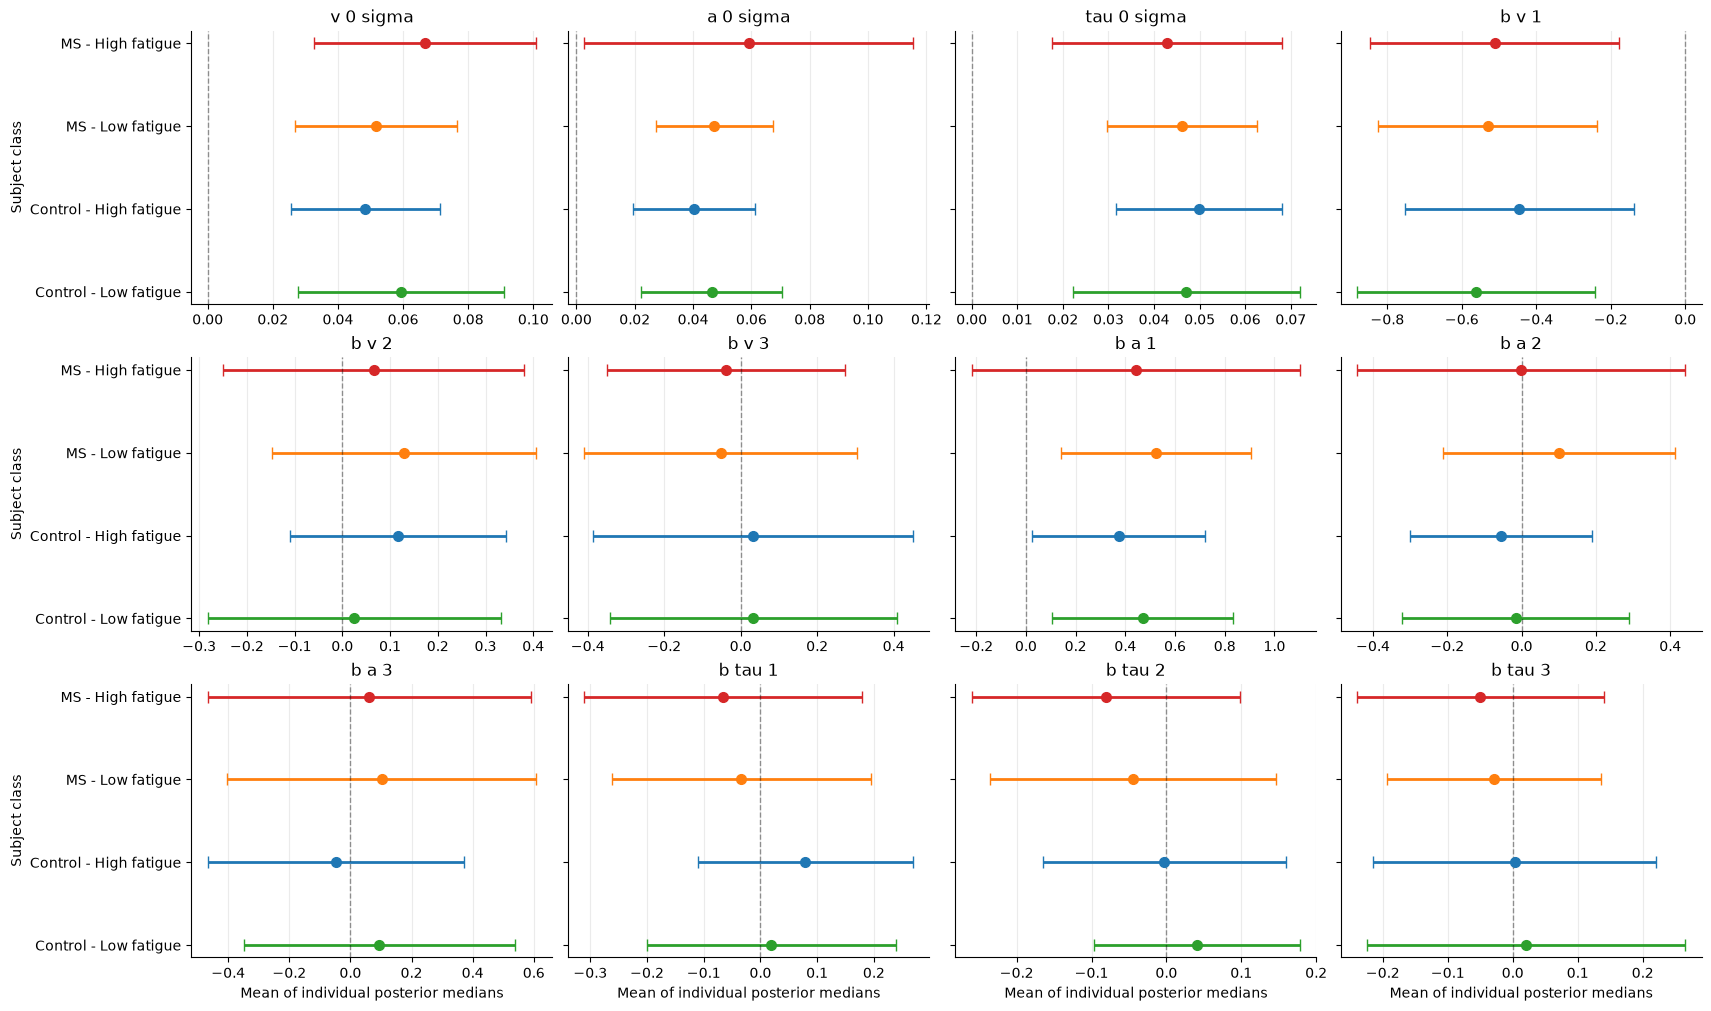

In [88]:
ncols = 4
nrows = int(np.ceil(len(time_invariant_params) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(17, 10),
    constrained_layout=True,
)

axes = np.asarray(axes).ravel()
y_positions = np.arange(len(class_names))[::-1]

for param_index, param in enumerate(time_invariant_params):
    ax = axes[param_index]

    row = param_index // ncols
    col = param_index % ncols

    for y, class_name in zip(y_positions, class_names):
        summary = class_summaries[param][class_name]

        ax.errorbar(
            x=summary["mean"],
            y=y,
            xerr=summary["sd"],
            fmt="o",
            color=class_colors[class_name],
            ecolor=class_colors[class_name],
            markersize=7,
            elinewidth=2,
            capsize=4,
        )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.4,
    )

    ax.set_title(
        param.replace("_", " "),
        fontsize=12,
    )

    ax.set_yticks(y_positions)

    # Show subject-class labels only in the first column
    if col == 0:
        ax.set_yticklabels(class_names)
        ax.set_ylabel("Subject class")
    else:
        ax.tick_params(
            axis="y",
            labelleft=False,
        )

    # Show the x-axis label only in the final row
    if row == nrows - 1:
        ax.set_xlabel(
            "Mean of individual posterior medians"
        )

    ax.grid(axis="x", alpha=0.25)

# Hide unused panels
for ax in axes[len(time_invariant_params):]:
    ax.set_visible(False)

sns.despine(fig=fig)